# Objectives
In the `statistical_close_encounters` example we derived post-encounter [a,e,i] purely from pre-encounter [a,e,i], sweeping gamma and psi over their full range since neither is resolved by that subset of orbital elements alone. That sweep is the **Surface of Variations**.

If the full set of orbital elements (or, equivalently, the full state vectors of both bodies) is available, gamma and psi are no longer free: they're rather fixed by the actual geometry of the encounter, and Tudat's `EphemerisOpikEncounter` gives a single, unambiguous post-encounter $[a_{post},e_{post},i_{post}]$. Here we use a real asteroid, (99942) Apophis, and its famous 13 April 2029 Earth encounter: the Surface of Variations is built from its pre-encounter $[a_{pre},e_{pre},i_{pre}]$ as retrieved from JPL's Small-Body Database (SBDB), and its real $(\gamma,\psi)$ point, and the resulting real $\Delta a, \Delta e, \Delta i$, is placed on top of it.

Apophis's real path during the 2029 encounter is itself shaped by Earth's gravity, so the real encounter below is built from **SPICE** ephemerides. 

# Import relevant modules
First, we import the relevant modules. Note the two OpikEncounter and EphemerisOpikEncounter classes. The former is the same we used in the previous example, while the latter allows us to use Tudat `Ephemeris` objects to compute the actual post-encounter geometry.

In [1]:
from tudatpy.astro.close_encounters.opik_encounters import OpikEncounter, EphemerisOpikEncounter
from tudatpy.interface import spice
from tudatpy.dynamics import environment_setup
import math
import numpy as np
import matplotlib.pyplot as plt
from tudatpy import constants
from datetime import datetime, timezone

# Reference Orbital Elements

Apophis's osculating elements $[a_{pre},e_{pre},i_{pre}]$ below are taken directly from [JPL SBDB](https://ssd-api.jpl.nasa.gov/sbdb.api?sstr=99942) (`orbit.elements`), at SBDB's own `orbit.epoch` (JD 2461200.5 TDB, i.e. 2026-06-09). These feed the idealized Surface of Variations below. The real encounter, further down, uses SPICE directly and doesn't need them.

`encounter_epoch` is Apophis's actual 2029 close approach as stated on SBDB: 2029-04-13 21:46 UTC.

In [15]:
AU = constants.ASTRONOMICAL_UNIT  # m
central_body_mass = 5.9722e24  # Earth mass, KG (actual mass, not a ratio)
central_body_radius = 6371.0e3  # Earth radius, meters
central_body_orbital_radius = 1.0 * AU

# Apophis, JPL SBDB (des=99942), orbit.epoch = JD 2461200.5 TDB
a, e, i_deg = 0.9223592206975018, 0.1911492279663492, 3.340996879880978
i = math.radians(i_deg)

encounter_epoch = (datetime(2029, 4, 13, 21, 46, tzinfo=timezone.utc) - datetime(2000, 1, 1, 12, tzinfo=timezone.utc)).total_seconds()

# Surface of Variations

Same computation as `statistical_close_encounters`, using Apophis's $[a,e,i]$: sweep $\gamma$ via a grid of $b$ values, sweep $\psi$ directly, and record how $[a,e,i]$ changes at each $(\gamma, \psi)$ pair.

In [16]:
gamma_values = np.linspace(0, np.pi, 50, endpoint=False)[1:]  # avoid gamma=0 (b=inf) and gamma=pi (b=0)
psi_values = np.linspace(0, 2 * np.pi, 50, endpoint=False)
Gamma, Psi = np.meshgrid(gamma_values, psi_values, indexing="ij")
mass_ratio = central_body_mass / OpikEncounter.SOLAR_MASS

seed = OpikEncounter([a, e, i], central_body_mass, central_body_radius, central_body_orbital_radius)
U = seed.planetocentric_velocity_magnitude_normalized

b_grid_normalized = mass_ratio / (U**2 * np.tan(gamma_values / 2))
b_grid_physical = b_grid_normalized * central_body_orbital_radius  # b's constructor arg is in meters

delta_a = np.empty((len(gamma_values), len(psi_values)))
delta_e = np.empty((len(gamma_values), len(psi_values)))
delta_i = np.empty((len(gamma_values), len(psi_values)))
for gi, b_phys in enumerate(b_grid_physical):
    for pj, psi in enumerate(psi_values):
        encounter = OpikEncounter(
            [a, e, i], central_body_mass, central_body_radius, central_body_orbital_radius,
            b=b_phys, psi=psi,
        )
        a_out, e_out, i_out = encounter.outgoing_orbital_elements
        delta_a[gi, pj] = a_out - a
        delta_e[gi, pj] = e_out - e
        delta_i[gi, pj] = i_out - i

# Real Encounter

Both ephemerides come straight from SPICE -- Earth from the standard kernels, Apophis from its own SPK, which we downloaded from SBDB and needs to be loaded. `EphemerisOpikEncounter` then derives $(\gamma, \psi)$ from the real relative geometry at `encounter_epoch`.

In [19]:
spice.load_standard_kernels()
spice.load_kernel("apophis.bsp")  # path to Apophis's own SPK kernel

earth_ephemeris_settings = environment_setup.ephemeris.direct_spice(
    frame_origin="SSB", frame_orientation="ECLIPJ2000", body_name_to_use="Earth",
)
earth_ephemeris = environment_setup.create_body_ephemeris(earth_ephemeris_settings, "Earth")

apophis_ephemeris_settings = environment_setup.ephemeris.direct_spice(
    frame_origin="SSB", frame_orientation="ECLIPJ2000", body_name_to_use="20099942",  # Apophis, NAIF ID
)
apophis_ephemeris = environment_setup.create_body_ephemeris(apophis_ephemeris_settings, "Apophis")

real_encounter = EphemerisOpikEncounter(
    small_body_ephemeris=apophis_ephemeris,
    planet_ephemeris=earth_ephemeris,
    central_body_mass=central_body_mass,
    central_body_radius=central_body_radius,
    encounter_epoch=encounter_epoch,
)

real_gamma = real_encounter.deflection_angle
real_psi = real_encounter.psi
a_out_real, e_out_real, i_out_real = real_encounter.outgoing_orbital_elements
real_delta_a = a_out_real - real_encounter.a
real_delta_e = e_out_real - real_encounter.e
real_delta_i = i_out_real - real_encounter.i

print(f"|U|       = {real_encounter.planetocentric_velocity_magnitude_physical/1000:.6f} [m/s]")
print(f"b           = {real_encounter.b_physical / 1000:.2f} [km]")
print(f"psi  = {math.degrees(real_psi):.4f} [deg]")
print(f"deflection gamma    = {math.degrees(real_gamma):.4f} [deg]")
print(f"delta a, e, i = {real_delta_a:.6f}, {real_delta_e:.6f}, {math.degrees(real_delta_i):.4f} [deg]")

|U|       = 7.422540 [m/s]
b           = 38010.95 [km]
psi  = -10.5110 [deg]
deflection gamma    = 21.5534 [deg]
delta a, e, i = 0.244197, 0.066426, 0.3944 [deg]


# Plot the Surface of Variations, with the real encounter overlaid

The surface represents every possible $(\gamma, \psi)$ outcome for Apophis's pre-encounter $[a,e,i]$ The red star is the one outcome that actually occurs on 13 April 2029, given the real, SPICE-derived state vectors of both bodies. 

Notice how the red star in general does not lie on the surface of variations?
This is because the Surface of Variations was computed using Keplerian elements instead of an actual ephemeris. This is enough to change the relative velocity vector between the asteroid and the Earth differs from the one retrieved in this simplified Keplerian case. Since the post-encounter values depend on this velocity, they will in general lie outside of the Surface of Variations.

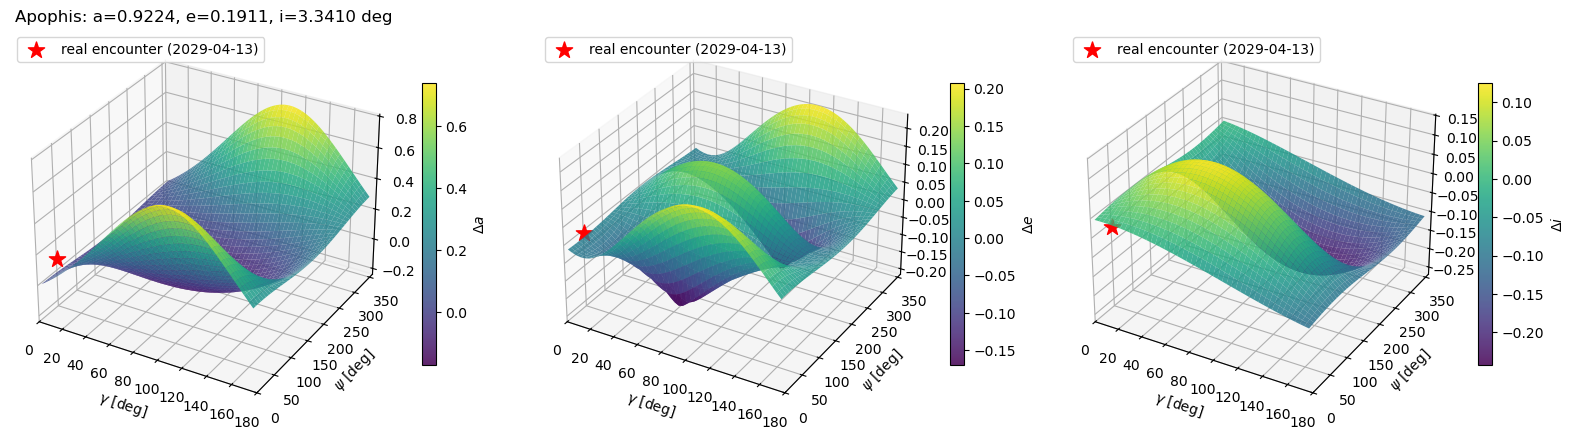

In [20]:
fig = plt.figure(figsize=(16, 5))
surfaces = [
    (delta_a, r"$\Delta a$", real_delta_a),
    (delta_e, r"$\Delta e$", real_delta_e),
    (delta_i, r"$\Delta i$", real_delta_i),
]
for col, (delta, label, real_delta) in enumerate(surfaces):
    ax = fig.add_subplot(1, 3, col + 1, projection="3d")
    surf = ax.plot_surface(np.degrees(Gamma), np.degrees(Psi), delta, cmap="viridis", edgecolor="none", alpha=0.85)
    ax.scatter(
        math.degrees(real_gamma), math.degrees(real_psi), real_delta,
        color="red", marker="*", s=150, zorder=10, label="real encounter (2029-04-13)",
    )

    ax.set_xlabel(r"$\gamma$ [deg]")
    ax.set_ylabel(r"$\psi$ [deg]")
    ax.set_zlabel(label)
    ax.set_xlim(0, 180)
    ax.set_ylim(0, 360)
    if col == 0:
        ax.set_title(f"Apophis: a={a:.4f}, e={e:.4f}, i={i_deg:.4f} deg")

    fig.colorbar(surf, ax=ax, shrink=0.6, label=label)
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()